# DuoAlign tutorial — human lymph node slice2

| item | value |
|---|---|
| dataset | 10x Genomics Visium CytAssist, human lymph node section **slice2** |
| omics | transcriptome (RNA) + surface protein (ADT) |
| spots | 3359 |
| ground-truth domains | 10 |
| pretraining epochs | 350 |

**Pipeline** — one code cell per step, run top to bottom:

| cell | step |
|---|---|
| 0 | environment variables and project paths |
| 1 | imports |
| 2 | hyper-parameters |
| 3 | load data and build labels |
| 4 | preprocessing (HVG -> normalise -> log1p -> scale -> PCA) |
| 5 | graph construction (shared spatial graph + per-omics semantic graphs) |
| 6 | train DuoAlign (stage-1 pretraining + KMeans) |
| 7 | clustering metrics |
| 8 | spatial clustering map (ground truth vs DuoAlign) |
| 9 | cross-modal attention violin plot |
| 10 | UMAP of the learned joint embedding |

Figures are written to `DuoAlign/notebooks/figs/`.

**Note on keys.** The AnnData keys below still carry the historical `MHALGlue_` prefix
(`MHALGlue_cluster`, `MHALGlue_emb`, `MHALGlue_alpha_cross`). They are kept on purpose: the
evaluation scripts in the workspace root read these exact names, so results written by this
notebook can be fed straight into `eval_cluster_comparison.py` and friends.


In [1]:
# ---------------------------------------------------------------------------
# 0. 环境与路径
#    固定哈希种子与线程数, 与 run_scripts/ 下的正式脚本保持一致, 保证结果可复现。
# ---------------------------------------------------------------------------
import os
import sys

os.environ['PYTHONHASHSEED'] = '2026'
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
for _v in ['OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
           'VECLIB_MAXIMUM_THREADS', 'NUMEXPR_NUM_THREADS']:
    os.environ[_v] = '1'


def _find_project_root(start=None):
    """向上查找含 DuoAlign/model.py 的目录, 使 notebook 在任意工作目录下都能运行。"""
    p = os.path.abspath(start or os.getcwd())
    for _ in range(8):
        if os.path.isfile(os.path.join(p, 'DuoAlign', 'model.py')):
            return p
        parent = os.path.dirname(p)
        if parent == p:
            break
        p = parent
    raise RuntimeError('未能自动定位项目根目录, 请在环境中设置 DUOALIGN_ROOT')


# 三个路径都可用环境变量覆盖:
#   DUOALIGN_ROOT      项目根 (含 DuoAlign/ 包)
#   DUOALIGN_DATA_ROOT 数据根 (默认 项目根/../data)
PROJECT_ROOT = os.environ.get('DUOALIGN_ROOT') or _find_project_root()
WORKSPACE_ROOT = os.path.dirname(PROJECT_ROOT)
DATA_ROOT = os.environ.get('DUOALIGN_DATA_ROOT') or os.path.join(WORKSPACE_ROOT, 'data')
FIG_DIR = os.path.join(PROJECT_ROOT, 'notebooks', 'figs')
os.makedirs(FIG_DIR, exist_ok=True)

# 让 `import DuoAlign` 生效
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print('PROJECT_ROOT =', PROJECT_ROOT)
print('DATA_ROOT    =', DATA_ROOT)
print('FIG_DIR      =', FIG_DIR)


PROJECT_ROOT = /mnt/data/jzhang/project/MHAL-Glue/DuoAlign
DATA_ROOT    = /mnt/data/jzhang/project/MHAL-Glue/data
FIG_DIR      = /mnt/data/jzhang/project/MHAL-Glue/DuoAlign/notebooks/figs


In [2]:
# ---------------------------------------------------------------------------
# 1. 依赖导入
#    DuoAlign 自身的三个模块: preprocess(构图/预处理) / train_duoalign(训练器) /
#    utils(评估指标)。这三个都来自 DuoAlign/ 包, 即上一步加入 sys.path 的目录。
# ---------------------------------------------------------------------------
import warnings

import numpy as np
import pandas as pd
import scanpy as sc
import torch
import matplotlib
try:
    # 在 Jupyter 里切到 inline 后端 -> 图直接显示在 cell 下方
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    # 普通脚本 / 无头执行时退回 Agg, 图仍由 savefig 写到磁盘
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment   # 匈牙利匹配, 用于聚类着色对齐
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

from DuoAlign.preprocess import fix_seed, construct_duoalign_graphs
from DuoAlign.train_duoalign import Train_DuoAlign
from DuoAlign.utils import evaluate_clustering

warnings.filterwarnings('ignore', category=UserWarning)
sc.settings.verbosity = 1

DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print('scanpy', sc.__version__, '| torch', torch.__version__, '| device', DEVICE)


scanpy 1.9.3 | torch 2.3.1+cu121 | device cuda:0


In [3]:
# ---------------------------------------------------------------------------
# 2. 超参数
#    默认值即论文与 run_scripts/ 采用的配置, 一般不需要改动。
#
#    图结构   spatial_k = 10   共享空间图: 欧氏距离 KNN
#             feature_k = 20   每组学各自的语义图: 余弦相似度 KNN
#    隐空间   dim_out       = 64
#    原型池   n_prototypes  = 32, Sinkhorn eps = 0.05, iters = 50, tau_pcl = 0.1
#    损失     phi = 0.5  (PSA 与重构项取 phi, PCL 取 1-phi)
#             lambda_ortho = 0.01 (原型正交正则)
#    优化     lr = 1e-3, weight_decay = 5e-4
#    预处理   n_top_genes = 3000, PCA 维度 RNA 200 / 第二组学 50
# ---------------------------------------------------------------------------
class Args:
    dataset_dir = os.path.join(DATA_ROOT, 'Human_lymph_node', 'slice2')

    random_state = 2022        # KMeans 与 PCA 共用同一随机种子
    use_dense_adj = True       # 稠密邻接: 结果严格确定, 推荐用于复现

    dim_out = 64
    n_prototypes = 32
    tau_pcl = 0.1
    sinkhorn_eps = 0.05
    sinkhorn_iters = 50
    use_saf = True             # 启用自适应融合模块 (SAF)
    spatial_k = 10
    feature_k = 20

    lr = 1e-3
    weight_decay = 5e-4
    pretrain_epochs = 350
    phi = 0.5
    lambda_ortho = 0.01

    n_top_genes = 3000
    pca_comps_rna = 200
    pca_comps_pro = 50

    label_key = 'final_annot'

args = Args()
fix_seed(args.random_state)     # 见 DuoAlign/preprocess.py, 固定 python/numpy/torch 种子
print('spatial_k =', args.spatial_k, '| feature_k =', args.feature_k,
      '| epochs =', args.pretrain_epochs, '| seed =', args.random_state)


spatial_k = 10 | feature_k = 20 | epochs = 350 | seed = 2022


In [4]:
# ---------------------------------------------------------------------------
# 3. 读取数据与标签
#    两个组学各自一个 h5ad; 标签直接来自 RNA 的 obs 列 final_annot。
#    两组学的 spot 顺序按 RNA 对齐, 保证逐行一一对应。
# ---------------------------------------------------------------------------
rna_path = os.path.join(args.dataset_dir, 's2_adata_rna.h5ad')
omics2_path = os.path.join(args.dataset_dir, 's2_adata_adt.h5ad')

adata_rna = sc.read_h5ad(rna_path)
adata_pro = sc.read_h5ad(omics2_path)
adata_rna.var_names_make_unique()
adata_pro.var_names_make_unique()

if args.label_key not in adata_rna.obs.columns:
    raise KeyError("label column '%s' not in obs; available: %s"
                   % (args.label_key, list(adata_rna.obs.columns)))

# 'manual-anno' 是 DuoAlign 内部统一使用的真值列名
adata_rna.obs['manual-anno'] = adata_rna.obs[args.label_key].astype(str)
adata_pro = adata_pro[adata_rna.obs_names].copy()

# 标签编码成 0..K-1; n_clusters 即 KMeans 的簇数(= 真实类别数)
le = LabelEncoder()
adata_rna.obs['Group'] = le.fit_transform(adata_rna.obs['manual-anno'].astype(str))
n_clusters = len(le.classes_)
print('cells = %d | ground-truth classes = %d' % (adata_rna.n_obs, n_clusters))
print('labels:', list(le.classes_))


cells = 3359 | ground-truth classes = 10
labels: ['capsule', 'cortex', 'follicle', 'hilum', 'medulla cords', 'medulla sinuses', 'medulla vessel', 'pericapsular adipose tissue', 'subcapsular sinus', 'trabeculae']


In [5]:
# ---------------------------------------------------------------------------
# 4. 预处理
#    空间坐标 min-max 归一化到 [0,1] 后参与构图(图只看相对位置, 与量纲无关)。
# ---------------------------------------------------------------------------
_coords = np.asarray(adata_rna.obsm['spatial'], dtype=np.float64)
adata_rna.obsm['spatial'] = _coords
coords_norm = ((_coords - _coords.min(axis=0)) /
               (_coords.max(axis=0) - _coords.min(axis=0)))

# --- 组学 1: 转录组 ---------------------------------------------------------
# 高变基因 -> 文库归一化 -> log1p -> 截断缩放 -> PCA, 结果存进 obsm['feat']
sc.pp.highly_variable_genes(adata_rna, flavor='seurat_v3', n_top_genes=args.n_top_genes)
sc.pp.normalize_total(adata_rna, target_sum=1e4)
sc.pp.log1p(adata_rna)
sc.pp.scale(adata_rna, zero_center=False, max_value=10)
sc.pp.pca(adata_rna, n_comps=args.pca_comps_rna, use_highly_variable=True,
          svd_solver='arpack', random_state=args.random_state)
adata_rna.obsm['feat'] = adata_rna.obsm['X_pca'].copy()

# --- 组学 2: protein (原始计数) ------------------------------------------
# 蛋白/ATAC 同样走 归一化 -> log1p -> 截断缩放 -> PCA。
# 维数取 min(50, n_vars-1): 蛋白 panel 通常不到 50 维, 此时 PCA 维度会被自动压小。
sc.pp.normalize_total(adata_pro, target_sum=1e4)
sc.pp.log1p(adata_pro)
sc.pp.scale(adata_pro, zero_center=False, max_value=10)
_n = min(args.pca_comps_pro, adata_pro.n_vars - 1)
if _n > 0:
    sc.pp.pca(adata_pro, n_comps=_n, svd_solver='arpack',
              random_state=args.random_state)
    adata_pro.obsm['feat'] = adata_pro.obsm['X_pca'].copy()
else:
    adata_pro.obsm['feat'] = np.asarray(adata_pro.X)

print('RNA feat:', adata_rna.obsm['feat'].shape,
      '| protein feat:', adata_pro.obsm['feat'].shape)


RNA feat: (3359, 200) | protein feat: (3359, 30)


In [6]:
# ---------------------------------------------------------------------------
# 5. 构图
#    construct_duoalign_graphs 一次返回三张图:
#      adj_spatial   两组学共享的空间图 (欧氏 KNN, k=spatial_k), 对称化 + 自环 + D^-1/2 A D^-1/2
#      adj_feature1  组学 1 的语义图 (余弦 KNN, k=feature_k)
#      adj_feature2  组学 2 的语义图 (同上)
#    空间图共享、语义图各自独立, 正是 DuoAlign 双视图编码的前提。
# ---------------------------------------------------------------------------
print('Building DuoAlign graphs (shared spatial + per-omics semantic)...')
graphs = construct_duoalign_graphs(coords_norm,
                                   adata_rna.obsm['feat'], adata_pro.obsm['feat'],
                                   spatial_k=args.spatial_k, feature_k=args.feature_k)
print('graph keys:', list(graphs.keys()))
for _k, _v in graphs.items():
    print('  %-14s shape = %s' % (_k, tuple(_v.shape)))


Building DuoAlign graphs (shared spatial + per-omics semantic)...
Building DuoAlign graphs: spatial_k=10, feature_k=20


graph keys: ['adj_spatial', 'adj_feature1', 'adj_feature2']
  adj_spatial    shape = (3359, 3359)
  adj_feature1   shape = (3359, 3359)
  adj_feature2   shape = (3359, 3359)


In [7]:
# ---------------------------------------------------------------------------
# 6. 训练 DuoAlign
#    Train_DuoAlign 接收 {'adata_omics1','adata_omics2','graphs'} 与超参, 提供两个入口:
#      pretrain()  —— 阶段一, 单组学预训练 (DuoAlign 只用这一阶段)
#    训练完成后对 z_cross 做 KMeans 得到最终空间域标签。
# ---------------------------------------------------------------------------
data_dict = {'adata_omics1': adata_rna, 'adata_omics2': adata_pro, 'graphs': graphs}

trainer = Train_DuoAlign(data_dict, args)
print('=== Stage 1: single-omics pretraining (%d epochs) ===' % args.pretrain_epochs)
init_z = trainer.pretrain()          # 返回阶段一的 z_cross

# KMeans 协议与论文一致: n_init=20, seed=2022, 簇数=真实类别数
print('\n=== KMeans on the learned joint embedding ===')
kmeans = KMeans(n_clusters=n_clusters, n_init=20, random_state=args.random_state)
final_labels = kmeans.fit_predict(init_z.cpu().numpy())

# ---------------------------------------------------------------------------
# 把结果写回 AnnData, 键名沿用 MHALGlue_ 前缀以便接上工作区的评估脚本
#   obsm['MHALGlue_emb']          联合嵌入 z_cross  (UMAP 图用)
#   obs['MHALGlue_cluster']       聚类标签         (聚类图 / 小提琴图用)
#   obsm['MHALGlue_alpha_cross']  跨模态注意力权重 (小提琴图用)
#   obs['MHALGlue_eta1'/'eta2']   两视图的全局融合系数 (诊断量)
# ---------------------------------------------------------------------------
with torch.no_grad():
    trainer.model.eval()
    res_final = trainer._forward()

adata_rna.obsm['MHALGlue_emb'] = res_final['z_cross'].cpu().numpy()
adata_rna.obs['MHALGlue_cluster'] = pd.Categorical(final_labels)
if res_final.get('alpha_cross') is not None:
    adata_rna.obsm['MHALGlue_alpha_cross'] = res_final['alpha_cross'].cpu().numpy()
if res_final.get('eta1') is not None:
    adata_rna.obs['MHALGlue_eta1'] = float(np.asarray(res_final['eta1'].cpu()))
    adata_rna.obs['MHALGlue_eta2'] = float(np.asarray(res_final['eta2'].cpu()))

print('clusters:', len(np.unique(final_labels)), '| embedding:', adata_rna.obsm['MHALGlue_emb'].shape)


Dense adjacency mode (deterministic): (3359, 3359)


✅ DuoAlign model initialized (167,344 trainable params) | ablations: share_spatial=True share_feature=False share_protos=True cross_attn=True w_fusion=True depth=2 fixed_eta=None
=== Stage 1: single-omics pretraining (350 epochs) ===
🚀 [Stage 1] Pretraining DuoAlign front-ends (phi=0.5, n_prototypes=32)...


EP 000 | Loss 6.2549 | PSA 0.0701 | Recon 3.8980 | PCL 8.2612 | Ortho 14.0295 | eta1 0.464 eta2 0.467 | ACC 0.3468 ARI 0.1601


EP 050 | Loss 4.3762 | PSA 0.0205 | Recon 3.7117 | PCL 4.8598 | Ortho 8.0122 | eta1 0.489 eta2 0.525 | ACC 0.4754 ARI 0.2611


EP 100 | Loss 3.7240 | PSA 0.0118 | Recon 3.5216 | PCL 3.8124 | Ortho 5.1035 | eta1 0.480 eta2 0.592 | ACC 0.4489 ARI 0.2510


EP 150 | Loss 3.3401 | PSA 0.0079 | Recon 3.4542 | PCL 3.1511 | Ortho 3.3442 | eta1 0.481 eta2 0.625 | ACC 0.5519 ARI 0.3138


EP 200 | Loss 3.0768 | PSA 0.0064 | Recon 3.4022 | PCL 2.6972 | Ortho 2.3853 | eta1 0.466 eta2 0.636 | ACC 0.5630 ARI 0.3211


EP 250 | Loss 2.9202 | PSA 0.0055 | Recon 3.3755 | PCL 2.4209 | Ortho 1.9235 | eta1 0.454 eta2 0.630 | ACC 0.5918 ARI 0.3192


EP 300 | Loss 2.7948 | PSA 0.0049 | Recon 3.3593 | PCL 2.1933 | Ortho 1.6038 | eta1 0.450 eta2 0.625 | ACC 0.5484 ARI 0.2975


EP 349 | Loss 2.7257 | PSA 0.0046 | Recon 3.3477 | PCL 2.0717 | Ortho 1.3697 | eta1 0.453 eta2 0.621 | ACC 0.5716 ARI 0.3255
✅ Stage 1 complete!

=== KMeans on the learned joint embedding ===
clusters: 10 | embedding: (3359, 64)


DuoAlign on human lymph node slice2  --  clustering metrics
ARI        |     0.3020
NMI        |     0.3753
AMI        |     0.3709
FMI        |     0.4642
F1         |     0.5534
Compl      |     0.3807
Jaccard    |     0.3826
ACC        |     0.5534
MI         |     0.6435
V-Measure  |     0.3753


saved: /mnt/data/jzhang/project/MHAL-Glue/DuoAlign/notebooks/figs/03_Human_lymph_node_slice2_metrics.png


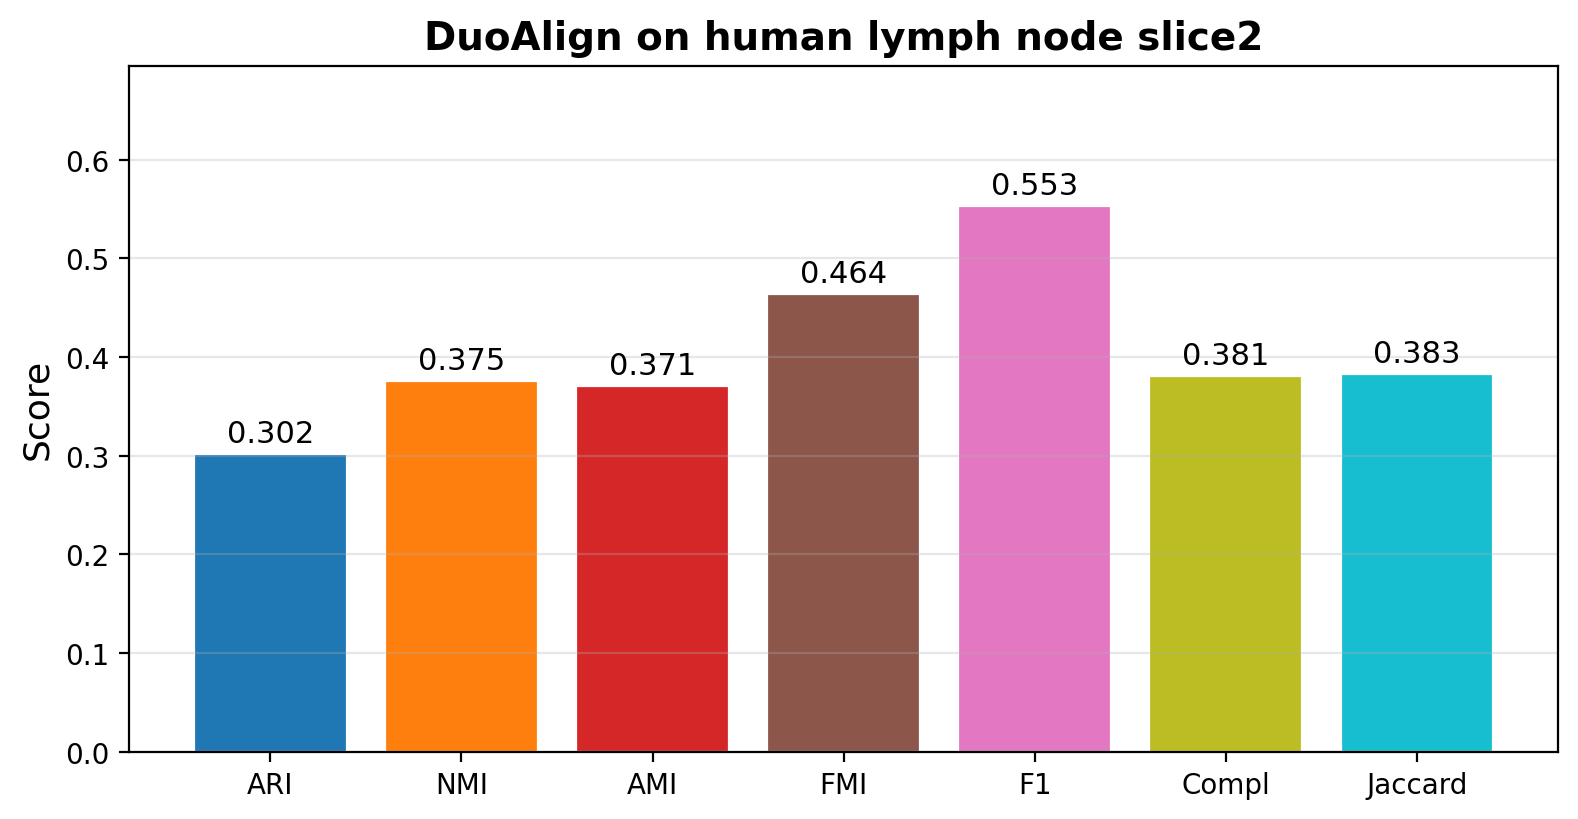

In [8]:
# ---------------------------------------------------------------------------
# 7. 指标展示
#    evaluate_clustering 内部先做匈牙利匹配把预测簇对齐到真实类, 再算 10 个指标。
#    论文正文引用的是 ARI / FMI / Completeness 三项。
# ---------------------------------------------------------------------------
y_true = adata_rna.obs['Group'].values
metrics = evaluate_clustering(y_true, final_labels)

order = ['ARI', 'NMI', 'AMI', 'FMI', 'F1', 'Compl', 'Jaccard']
print('=' * 58)
print('DuoAlign on human lymph node slice2  --  clustering metrics')
print('=' * 58)
for _k in order:
    print('%-10s | %10.4f' % (_k, metrics[_k]))
for _k, _v in metrics.items():          # 其余指标(ACC/MI/V-Measure 等)
    if _k not in order:
        print('%-10s | %10.4f' % (_k, _v))
print('=' * 58)

# 同一组指标画成柱状图, 便于快速对比
fig, ax = plt.subplots(figsize=(8, 4.2))
vals = [metrics[_k] for _k in order]
bars = ax.bar(order, vals, color=plt.cm.tab10(np.linspace(0, 1, len(order))),
              edgecolor='white', linewidth=0.8)
for _b, _v in zip(bars, vals):
    ax.text(_b.get_x() + _b.get_width() / 2, _v + 0.012, '%.3f' % _v,
            ha='center', fontsize=11)
ax.set_ylabel('Score', fontsize=13)
ax.set_ylim(0, min(1.05, max(vals) * 1.22 + 0.02))
ax.set_title('DuoAlign on human lymph node slice2', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
_p = os.path.join(FIG_DIR, '03_Human_lymph_node_slice2_metrics.png')
fig.savefig(_p, dpi=200, bbox_inches='tight')
plt.close(fig)
print('saved:', _p)

# 把落盘的 PNG 直接渲染出来: 不依赖 matplotlib 后端, 因此在 notebook 里一定显示
try:
    get_ipython()
    from IPython.display import Image, display
    display(Image(filename=_p))
except NameError:
    pass          # 转成 .py 用 python 跑时跳过


saved: /mnt/data/jzhang/project/MHAL-Glue/DuoAlign/notebooks/figs/03_Human_lymph_node_slice2_spatial.png


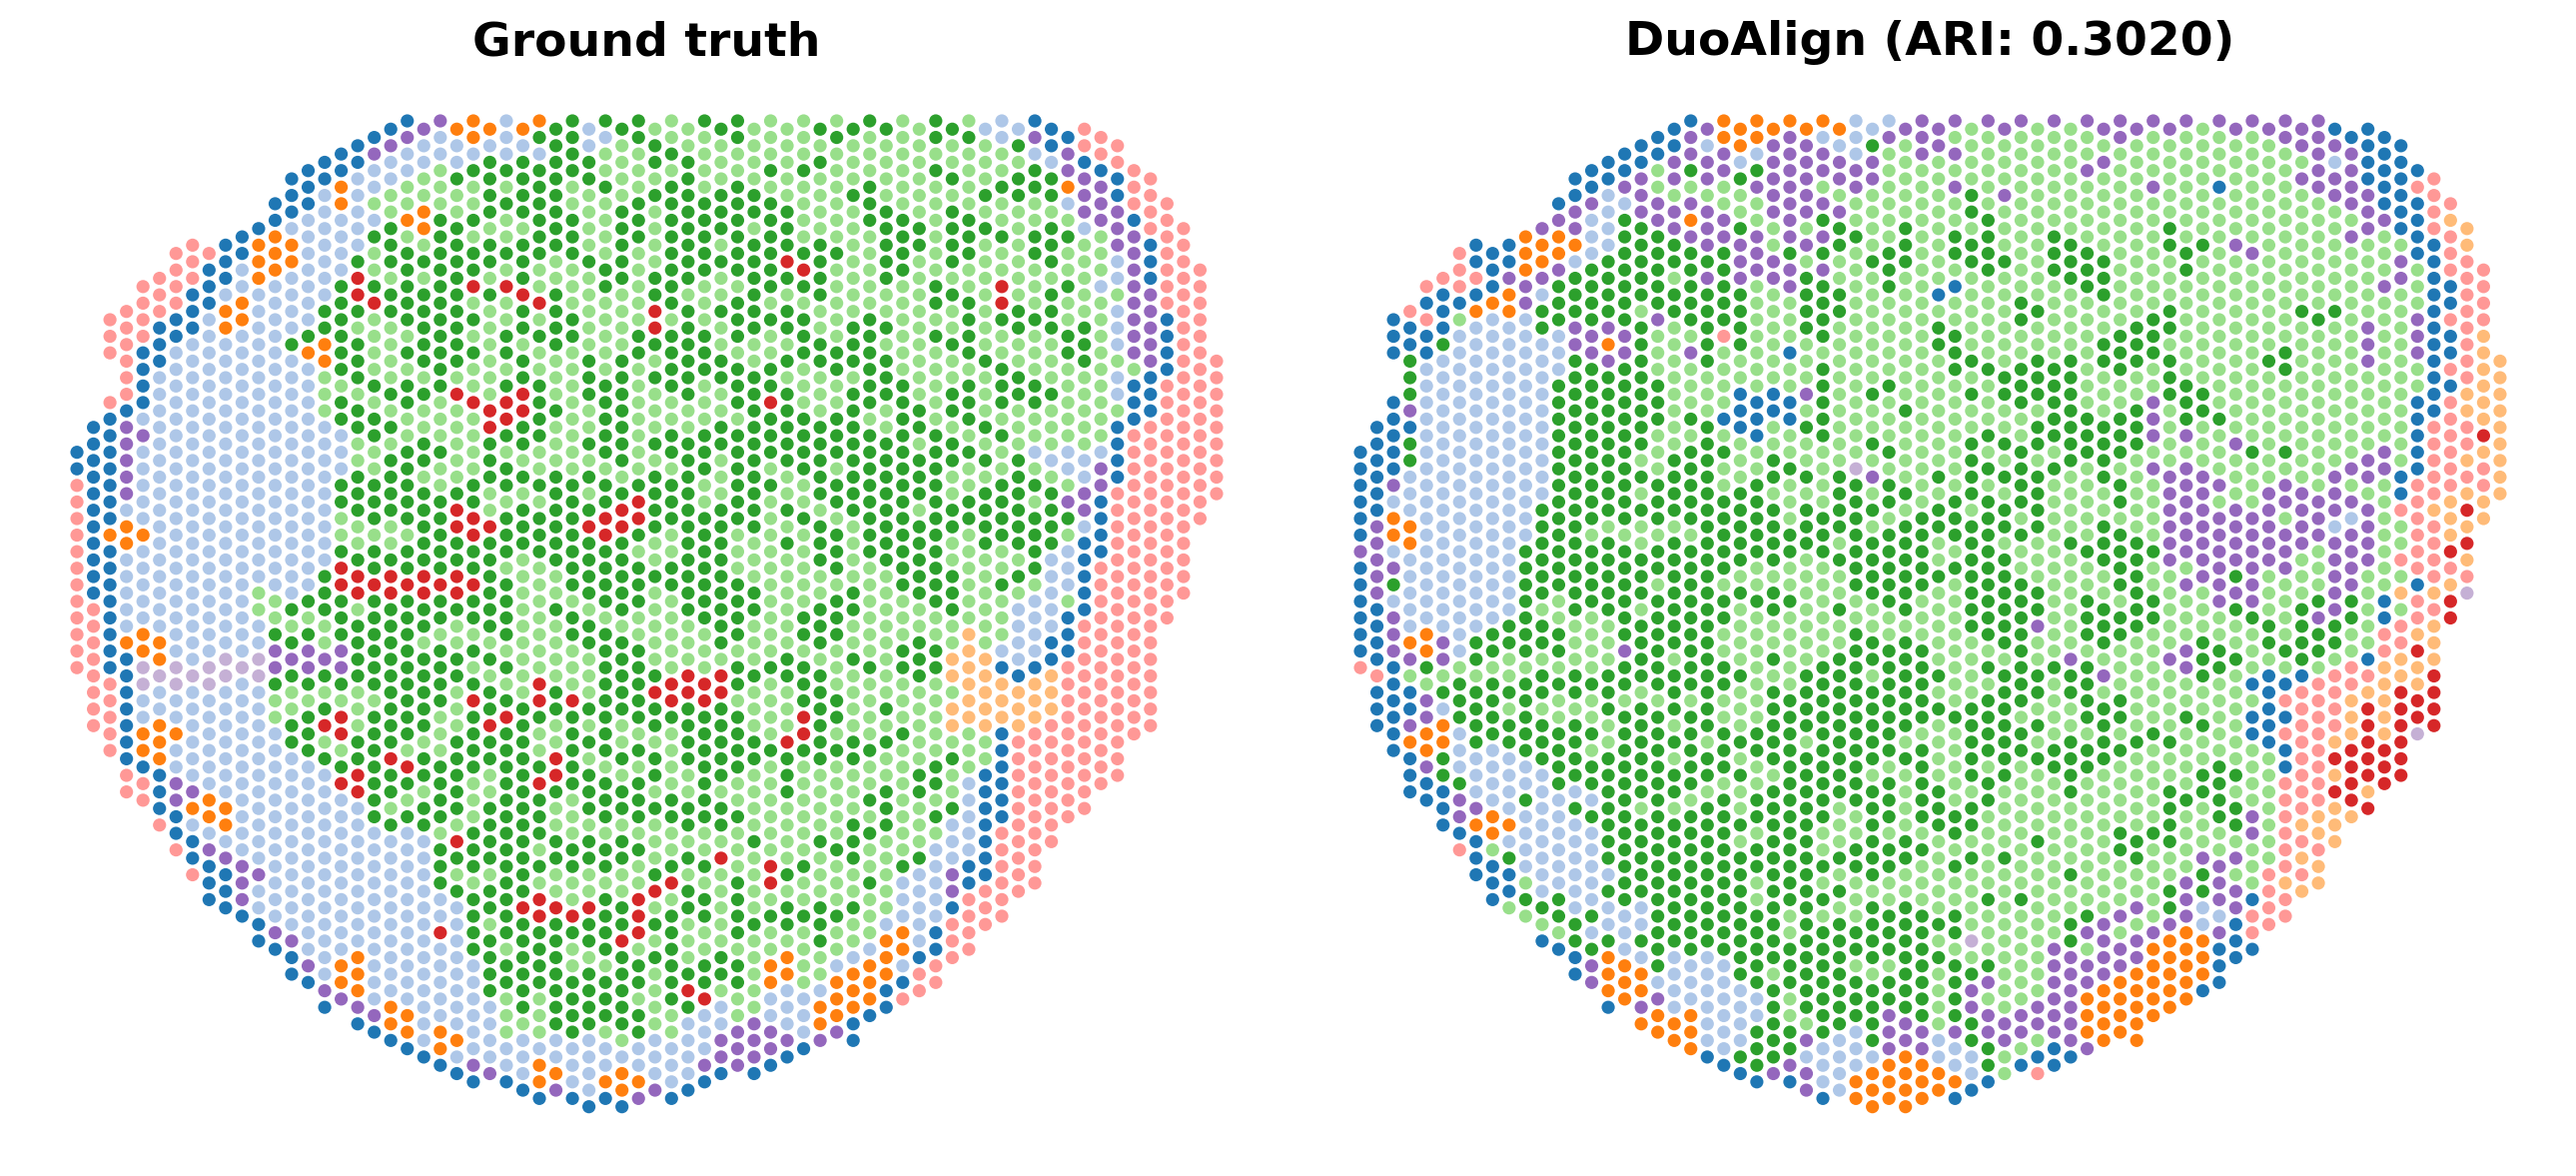

In [9]:
# ---------------------------------------------------------------------------
# 8. 聚类可视化 (空间图)
#    左: 人工标注的真值;  右: DuoAlign 预测。
#    预测簇先经匈牙利匹配对齐到真值类别, 这样左右同一颜色代表同一空间域。
#    个别预测簇匹配不到任何真值类时归入灰色 'others'。
# ---------------------------------------------------------------------------
def hungarian_map(y_true, y_pred):
    """匈牙利算法把预测簇映射到真值类别: 最大化混淆矩阵对角和。"""
    D = max(int(y_pred.max()), int(y_true.max())) + 1
    w = np.zeros((D, D), dtype=np.int64)
    for i in range(y_pred.size):
        w[y_pred[i], y_true[i]] += 1
    row, col = linear_sum_assignment(w.max() - w)
    mp = {r: c for r, c in zip(row, col)}
    return np.array([mp.get(p, D + p) for p in y_pred])


gt_names = np.unique(adata_rna.obs['manual-anno'].astype(str))
y_gt = np.searchsorted(gt_names, adata_rna.obs['manual-anno'].astype(str).values)
y_mapped = hungarian_map(y_gt, final_labels)

# 统一配色: tab20 前 K 个给真值类别, 最后一色给 'others'
all_names = list(gt_names) + ['others']
palette = [plt.cm.tab20(i % 20) for i in range(len(all_names))]
palette[-1] = '#bbbbbb'

plot_gt = adata_rna.copy()
plot_gt.obs['_c'] = pd.Categorical(
    np.array([gt_names[m] if m < len(gt_names) else 'others' for m in y_gt], dtype=str),
    categories=all_names)
plot_da = adata_rna.copy()
plot_da.obs['_c'] = pd.Categorical(
    np.array([gt_names[m] if m < len(gt_names) else 'others' for m in y_mapped], dtype=str),
    categories=all_names)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
sc.pl.embedding(plot_gt, basis='spatial', color='_c', palette=palette,
                size=90, show=False, ax=axes[0], legend_loc=None, title='')
sc.pl.embedding(plot_da, basis='spatial', color='_c', palette=palette,
                size=90, show=False, ax=axes[1], legend_loc=None, title='')
for _ax, _t in zip(axes, ['Ground truth', 'DuoAlign (ARI: %.4f)' % metrics['ARI']]):
    _ax.set_aspect('auto')      # 让点铺满面板, 避免留白
    _ax.axis('off')
    _ax.set_title(_t, fontsize=17, fontweight='bold')
fig.tight_layout()
_p = os.path.join(FIG_DIR, '03_Human_lymph_node_slice2_spatial.png')
fig.savefig(_p, dpi=200, bbox_inches='tight')
plt.close(fig)
print('saved:', _p)

# 把落盘的 PNG 直接渲染出来: 不依赖 matplotlib 后端, 因此在 notebook 里一定显示
try:
    get_ipython()
    from IPython.display import Image, display
    display(Image(filename=_p))
except NameError:
    pass          # 转成 .py 用 python 跑时跳过


saved: /mnt/data/jzhang/project/MHAL-Glue/DuoAlign/notebooks/figs/03_Human_lymph_node_slice2_attention_violin.png


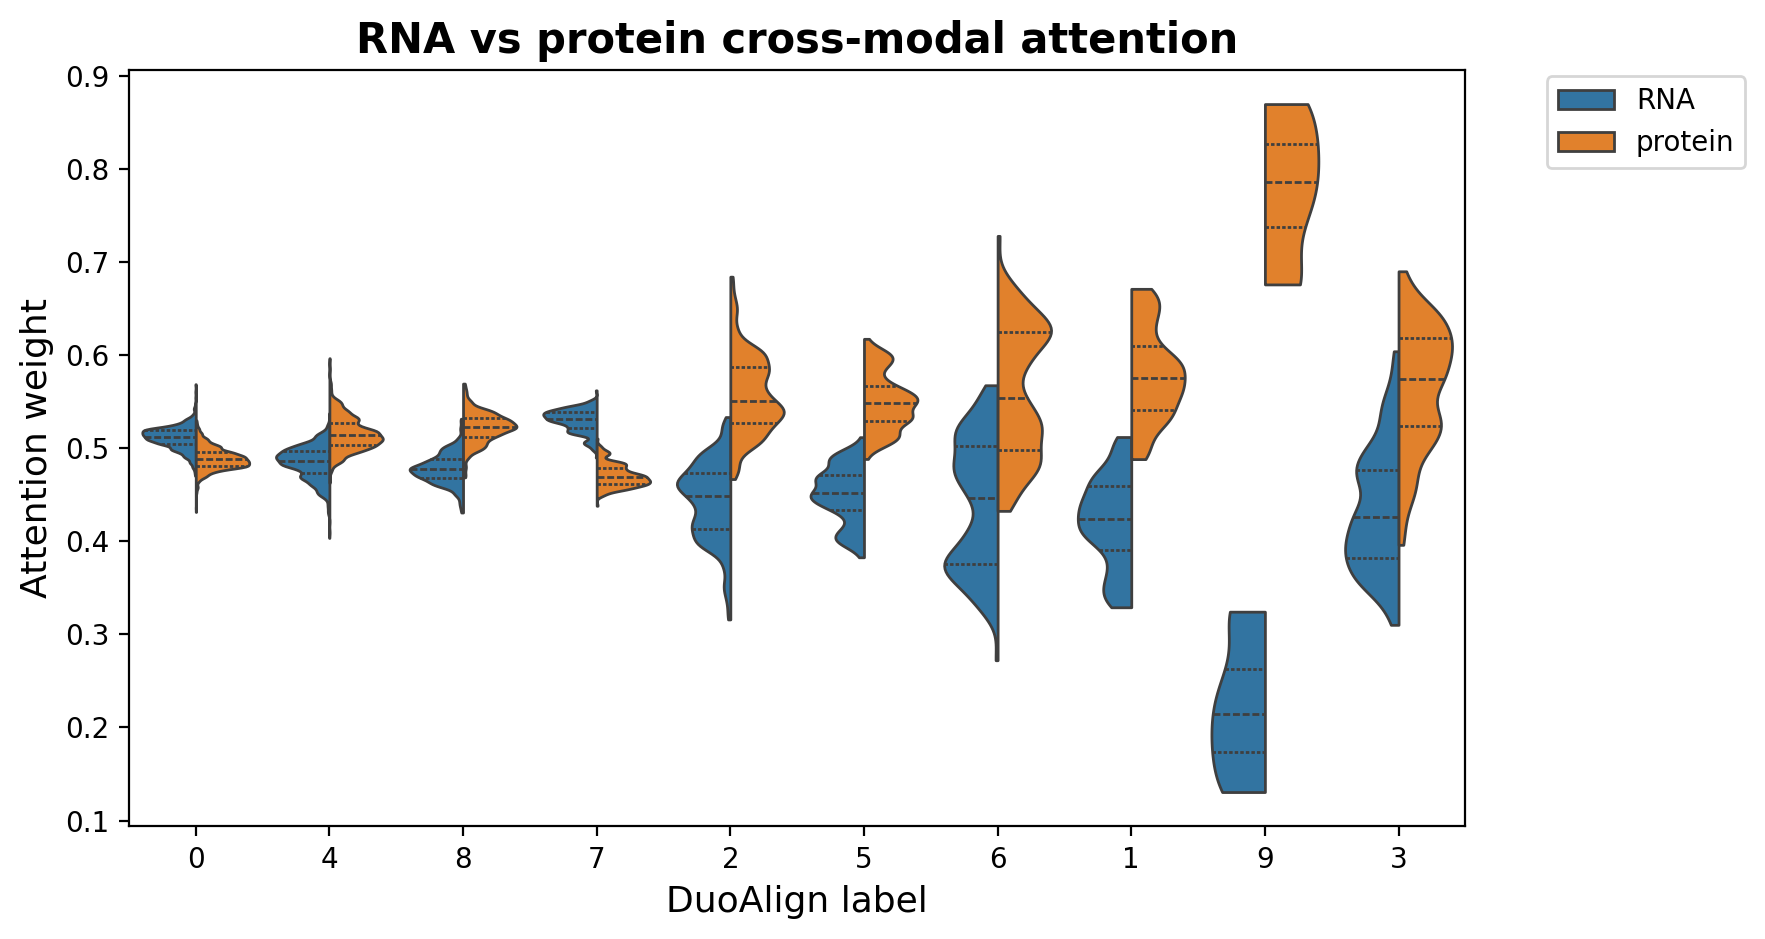

In [10]:
# ---------------------------------------------------------------------------
# 9. 跨模态注意力小提琴图
#    obsm['MHALGlue_alpha_cross'] 形状 (N, 2):
#      A[:, 0] = 每个 spot 在 RNA 上的权重
#      A[:, 1] = 每个 spot 在 protein 上的权重
#    两者之和为 1 (softmax 输出), 因此按聚类标签分组画 split violin,
#    可以直观看出"哪些域更依赖转录组、哪些域更依赖 protein"。
# ---------------------------------------------------------------------------
if 'MHALGlue_alpha_cross' in adata_rna.obsm:
    import seaborn as sns

    A = np.asarray(adata_rna.obsm['MHALGlue_alpha_cross'])
    df = pd.DataFrame(columns=['RNA', 'protein', 'label'])
    df['RNA'], df['protein'] = A[:, 0], A[:, 1]
    df['label'] = adata_rna.obs['MHALGlue_cluster'].astype(str).values
    # 宽表转长表, 供 seaborn 的 hue 使用
    df = df.set_index('label').stack().reset_index()
    df.columns = ['DuoAlign label', 'Modality', 'Attention weight']

    fig, ax = plt.subplots(figsize=(9, 4.8))
    sns.violinplot(data=df, x='DuoAlign label', y='Attention weight',
                   hue='Modality', split=True, inner='quart', linewidth=1,
                   cut=0, density_norm='width', bw_adjust=0.6, ax=ax)
    ax.set_title('RNA vs protein cross-modal attention', fontsize=15,
                 fontweight='bold')
    ax.set_xlabel('DuoAlign label', fontsize=13)
    ax.set_ylabel('Attention weight', fontsize=13)
    ax.legend(bbox_to_anchor=(1.22, 1.01), loc='upper right')
    fig.tight_layout()
    _p = os.path.join(FIG_DIR, '03_Human_lymph_node_slice2_attention_violin.png')
    fig.savefig(_p, dpi=200, bbox_inches='tight')
    plt.close(fig)
    print('saved:', _p)

    # 把落盘的 PNG 直接渲染出来: 不依赖 matplotlib 后端, 因此在 notebook 里一定显示
    try:
        get_ipython()
        from IPython.display import Image, display
        display(Image(filename=_p))
    except NameError:
        pass          # 转成 .py 用 python 跑时跳过
else:
    print("obsm['MHALGlue_alpha_cross'] not found -- re-run the training cell above")


2026-09-29 16:20:46.687933: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-29 16:20:46.703626: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


dim reduction: UMAP


saved: /mnt/data/jzhang/project/MHAL-Glue/DuoAlign/notebooks/figs/03_Human_lymph_node_slice2_umap.png


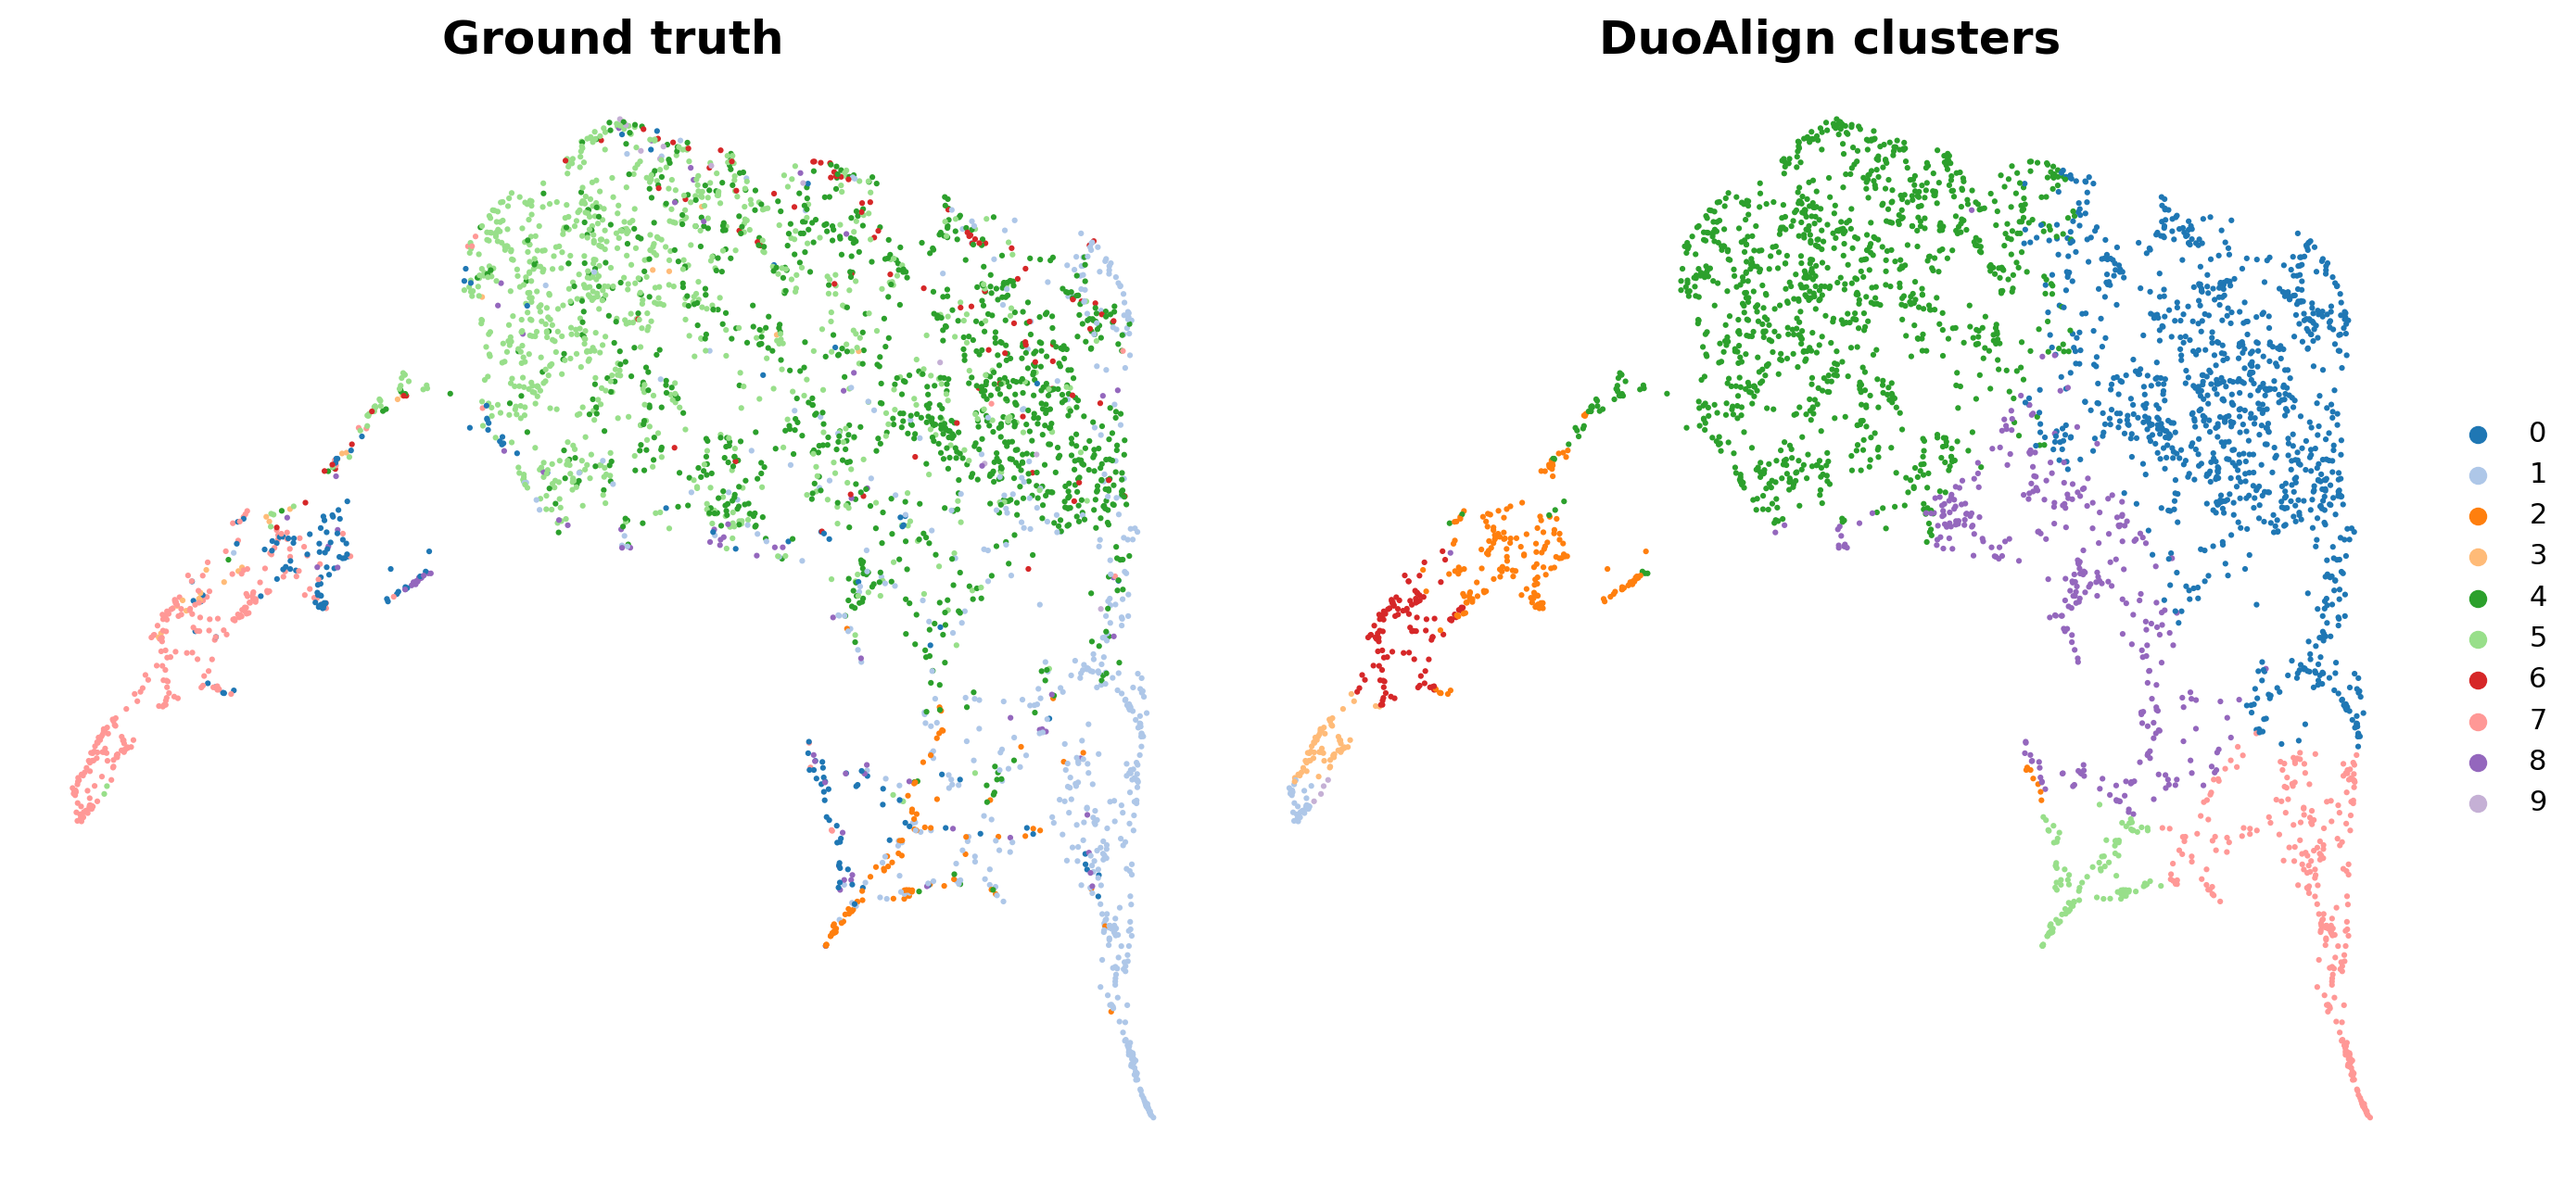

In [11]:
# ---------------------------------------------------------------------------
# 10. UMAP 图
#     左: 真值标签;  右: DuoAlign 聚类。
#     聚类越分离、与左图结构越一致, 说明学到的嵌入越线性可分。
#     - umap-learn 未安装时自动退化为 PCA 二维投影, 不报错。
#     - 注意: 这里的 size 控制点大小, 与上面聚类空间图的 size 意义相同(单位 pt^2)。
# ---------------------------------------------------------------------------
emb = np.asarray(adata_rna.obsm['MHALGlue_emb'])
try:
    import umap
    red = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42,
                    n_components=2).fit_transform(emb)
    method = 'UMAP'
except Exception as _e:
    from sklearn.decomposition import PCA
    red = PCA(n_components=2, random_state=42).fit_transform(emb)
    method = 'PCA (umap-learn not installed)'
print('dim reduction:', method)

_ad = adata_rna.copy()
_ad.obsm['_red'] = red
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
sc.pl.embedding(_ad, basis='_red', color='manual-anno', palette=palette,
                size=20, show=False, ax=axes[0], legend_loc=None, title='')
sc.pl.embedding(_ad, basis='_red', color='MHALGlue_cluster', palette=palette,
                size=20, show=False, ax=axes[1], legend_loc='right margin',
                legend_fontsize=11, title='')
for _ax, _t in zip(axes, ['Ground truth', 'DuoAlign clusters']):
    _ax.set_aspect('auto')
    _ax.axis('off')
    _ax.set_title(_t, fontsize=18, fontweight='bold')
fig.tight_layout()
_p = os.path.join(FIG_DIR, '03_Human_lymph_node_slice2_umap.png')
fig.savefig(_p, dpi=200, bbox_inches='tight')
plt.close(fig)
print('saved:', _p)

# 把落盘的 PNG 直接渲染出来: 不依赖 matplotlib 后端, 因此在 notebook 里一定显示
try:
    get_ipython()
    from IPython.display import Image, display
    display(Image(filename=_p))
except NameError:
    pass          # 转成 .py 用 python 跑时跳过
